# 아이돌봄서비스 종사자 분석

## Basic Settings

In [10]:
### 한글 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf
# 설치 후 colab의 경우 Runtime > Restart session 필요

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/dejavu
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/dejavu: caching, new cache contents: 22 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/dejavu: skipping, looped directory detecte

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='NanumBarunGothic') # 혹은 다른 설치한 Nanum 폰트 사용

In [12]:
import pandas as pd
import seaborn as sns
import numpy as np
import scipy
import scipy.stats as stats

## 2020년 활동돌보미 수 Data

### data 준비

In [13]:
# 2020년 지역별 아이돌보미 현황(활동돌보미 기준)
data = {
    "지역": [
        "제주특별자치도", "경상남도", "경상북도", "전라남도", "전라북도", "충청남도", "충청북도", "강원특별자치도", 
        "세종특별자치시", "울산광역시", "대전광역시", "광주광역시", "인천광역시", "대구광역시", "부산광역시", 
        "경기도", "서울특별시"
    ],
    "활동돌보미 수(명)": [
        337, 1548, 1946, 1074, 1096, 1046, 718, 1054, 329, 849, 596, 957, 1227, 1124, 1887, 5065, 3616
    ]
}

# DataFrame으로 변환
df_childcare_worker = pd.DataFrame(data)

df_childcare_worker

,지역,활동돌보미 수(명)
0,제주특별자치도,337
1,경상남도,1548
2,경상북도,1946
3,전라남도,1074
4,전라북도,1096
5,충청남도,1046
6,충청북도,718
7,강원특별자치도,1054
8,세종특별자치시,329
9,울산광역시,849


In [14]:
# 대한민국 인구통계 data 불러오기
# CSV 파일 경로
file_path = "../../dataset/Total population of South Korea/Total population of South Korea.csv"

# CSV 파일을 DataFrame으로 불러오기
df_population_Korea = pd.read_csv(file_path)

df_population_Korea

,행정구역별(읍면동),2015,2016,2017,2018,2019,2020,2021,2022,2023
0,행정구역별(읍면동),총인구 (명),총인구 (명),총인구 (명),총인구 (명),총인구 (명),총인구 (명),총인구 (명),총인구 (명),총인구 (명)
1,전국,51069375,51269554,51422507,51629512,51779203,51829136,51738071,51692272,51774521
2,읍부,4616802,4707855,4794377,4984023,5057507,5113052,5183834,5098892,5131418
3,면부,4774878,4793569,4835090,4730290,4698591,4650781,4534456,4506486,4536053
4,동부,41677695,41768130,41793040,41915199,42023105,42065303,42019781,42086894,42107050
...,...,...,...,...,...,...,...,...,...,...
325,읍부,129134,134561,141557,147773,151015,153767,153891,154606,155260
326,면부,31078,31890,33683,35323,35474,35539,35587,36397,37027
327,동부,445407,456881,466517,475186,478559,481552,483629,485372,484480
328,제주시,451758,462286,472399,482932,487688,492306,493869,495281,495553


### Data 전처리

In [15]:
# Data간의 연도 씽크 맞추기
# 불러온 대한민국 인구통계 DataFrame에서 2020년 데이터만 남기고
df_population_2020 = df_population_Korea[['행정구역별(읍면동)', '2020']]
df_population_2020

,행정구역별(읍면동),2020
0,행정구역별(읍면동),총인구 (명)
1,전국,51829136
2,읍부,5113052
3,면부,4650781
4,동부,42065303
...,...,...
325,읍부,153767
326,면부,35539
327,동부,481552
328,제주시,492306


In [16]:
# '행정구역별(읍면동)'에서 df_regions의 '지역'과 겹치는 행만 남기기
df_population_2020 = df_population_2020[df_population_2020['행정구역별(읍면동)'].isin(df_childcare_worker['지역'])]
df_population_2020

,행정구역별(읍면동),2020
5,서울특별시,9586195
31,부산광역시,3349016
51,대구광역시,2410700
64,인천광역시,2945454
79,광주광역시,1477573
85,대전광역시,1488435
91,울산광역시,1135423
100,세종특별자치시,353933
105,경기도,13511676
160,강원특별자치도,1521763


In [17]:
# 두 DataFrame을 '행정구역별(읍면동)'과 '지역' 기준으로 병합
df_merged = pd.merge(df_population_2020, df_childcare_worker, left_on='행정구역별(읍면동)', right_on='지역')

# '지역', '2020', '활동돌보미 수(명)' 순서로 컬럼 재정렬
df_population_childcare = df_merged[['지역', '2020', '활동돌보미 수(명)']]
df_population_childcare

# 2020 컬럼명을 인구 수(명)으로 변경
df_population_childcare.rename(columns={'2020': '인구 수(명)'}, inplace=True)
df_population_childcare

/tmp/ipykernel_22/3542470817.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_population_childcare.rename(columns={'2020': '인구 수(명)'}, inplace=True)


,지역,인구 수(명),활동돌보미 수(명)
0,서울특별시,9586195,3616
1,부산광역시,3349016,1887
2,대구광역시,2410700,1124
3,인천광역시,2945454,1227
4,광주광역시,1477573,957
5,대전광역시,1488435,596
6,울산광역시,1135423,849
7,세종특별자치시,353933,329
8,경기도,13511676,5065
9,강원특별자치도,1521763,1054


In [18]:
# 열의 데이터 타입을 문자열로 되어 있을 경우 정수형으로 변환합니다.
df_population_childcare['인구 수(명)'] = df_population_childcare['인구 수(명)'].astype(int)
df_population_childcare['활동돌보미 수(명)'] = df_population_childcare['활동돌보미 수(명)'].astype(int)

# 인구 수 대비 활동돌보미 수의 비율을 계산합니다.
df_population_childcare['인구 대비 활동돌보미 비율'] = df_population_childcare['활동돌보미 수(명)'] / df_population_childcare['인구 수(명)']
df_population_childcare

/tmp/ipykernel_22/3595428099.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_population_childcare['인구 수(명)'] = df_population_childcare['인구 수(명)'].astype(int)
/tmp/ipykernel_22/3595428099.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_population_childcare['활동돌보미 수(명)'] = df_population_childcare['활동돌보미 수(명)'].astype(int)


,지역,인구 수(명),활동돌보미 수(명),인구 대비 활동돌보미 비율
0,서울특별시,9586195,3616,0.000377
1,부산광역시,3349016,1887,0.000563
2,대구광역시,2410700,1124,0.000466
3,인천광역시,2945454,1227,0.000417
4,광주광역시,1477573,957,0.000648
5,대전광역시,1488435,596,0.000400
6,울산광역시,1135423,849,0.000748
7,세종특별자치시,353933,329,0.000930
8,경기도,13511676,5065,0.000375
9,강원특별자치도,1521763,1054,0.000693


### 활동돌보미 수 시각화

/tmp/ipykernel_22/2625212895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='활동돌보미 수(명)', y='지역', data=df_sorted, palette='viridis')


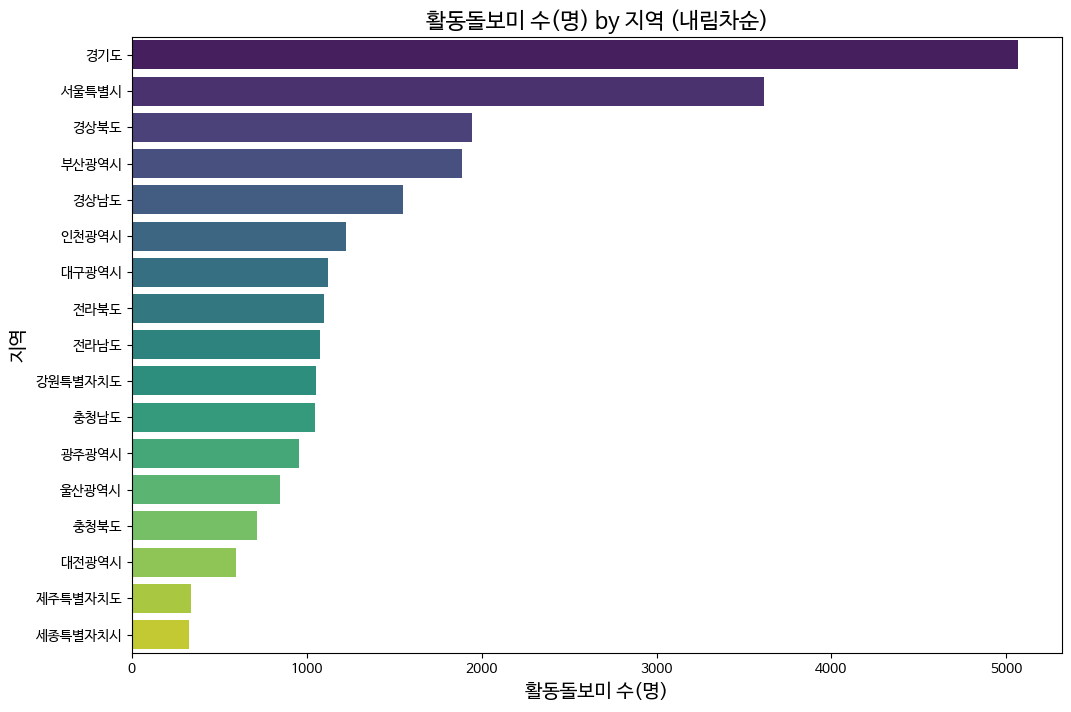

In [19]:
# 활동돌보미 수를 내림차순으로 정렬합니다.
df_sorted = df_population_childcare.sort_values(by='활동돌보미 수(명)', ascending=False)

# 시각화 설정
plt.figure(figsize=(12, 8))
sns.barplot(x='활동돌보미 수(명)', y='지역', data=df_sorted, palette='viridis')

# 그래프에 제목과 축 레이블을 추가합니다.
plt.title('활동돌보미 수(명) by 지역 (내림차순)', fontsize=16)
plt.xlabel('활동돌보미 수(명)', fontsize=14)
plt.ylabel('지역', fontsize=14)

# 그래프를 표시합니다.
plt.show()

/tmp/ipykernel_22/2625212895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='활동돌보미 수(명)', y='지역', data=df_sorted, palette='viridis')


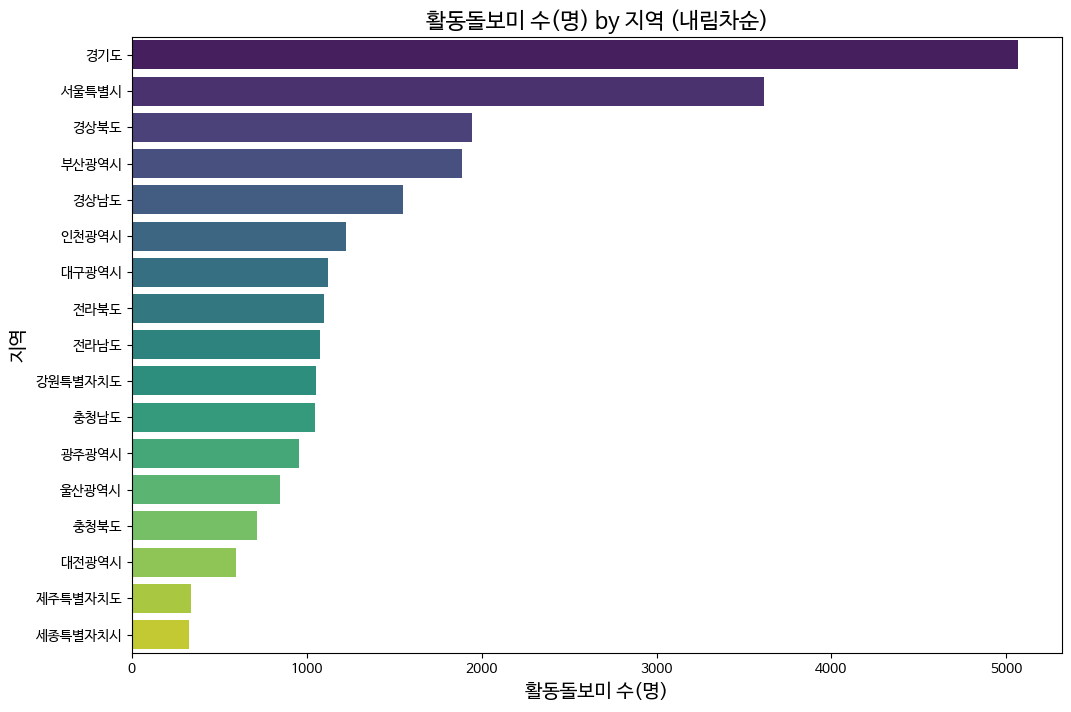

In [19]:
# 활동돌보미 수를 내림차순으로 정렬합니다.
df_sorted = df_population_childcare.sort_values(by='활동돌보미 수(명)', ascending=False)

# 시각화 설정
plt.figure(figsize=(12, 8))
sns.barplot(x='활동돌보미 수(명)', y='지역', data=df_sorted, palette='viridis')

# 그래프에 제목과 축 레이블을 추가합니다.
plt.title('활동돌보미 수(명) by 지역 (내림차순)', fontsize=16)
plt.xlabel('활동돌보미 수(명)', fontsize=14)
plt.ylabel('지역', fontsize=14)

# 그래프를 표시합니다.
plt.show()

/tmp/ipykernel_22/841292746.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='인구 대비 활동돌보미 비율', y='지역', data=df_sorted, palette='viridis')


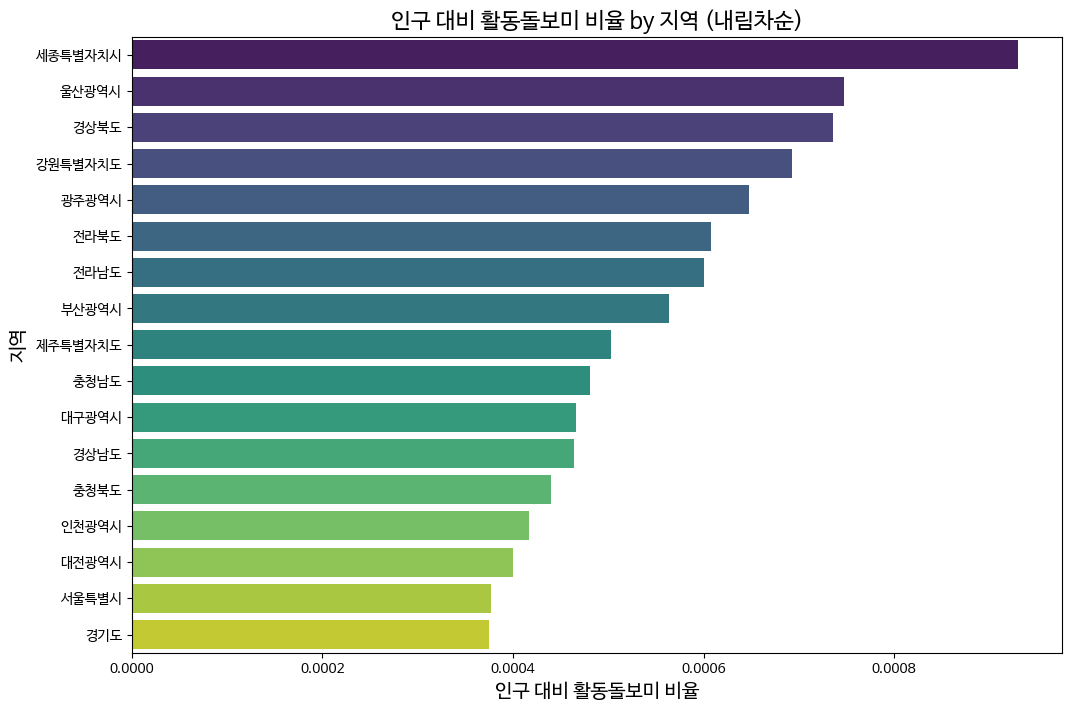

In [20]:
# 지역별 인구대비 활동돌보미 수 시각화

# 비율을 내림차순으로 정렬
df_sorted = df_population_childcare.sort_values(by='인구 대비 활동돌보미 비율', ascending=False)

# 시각화 설정
plt.figure(figsize=(12, 8))
sns.barplot(x='인구 대비 활동돌보미 비율', y='지역', data=df_sorted, palette='viridis')

# 그래프에 제목과 축 레이블을 추가
plt.title('인구 대비 활동돌보미 비율 by 지역 (내림차순)', fontsize=16)
plt.xlabel('인구 대비 활동돌보미 비율', fontsize=14)
plt.ylabel('지역', fontsize=14)

# 그래프 표시
plt.show()

## 2020년 아이돌보미 연령 분포 Data

### Data 준비

In [23]:
# 데이터 생성
data = {
    '연령대': ['40세 미만', '40세이상 45세미만', '45세이상 50세미만', '50세이상 55세미만', '55세이상 60세미만', '60세이상 65세미만', '65세 이상'],
    '인원수(명)': [137, 512, 2354, 5537, 7518, 5353, 1774]
}

# DataFrame으로 변환
df_childcare_age = pd.DataFrame(data)
df_childcare_age

,연령대,인원수(명)
0,40세 미만,137
1,40세이상 45세미만,512
2,45세이상 50세미만,2354
3,50세이상 55세미만,5537
4,55세이상 60세미만,7518
5,60세이상 65세미만,5353
6,65세 이상,1774


### 시각화

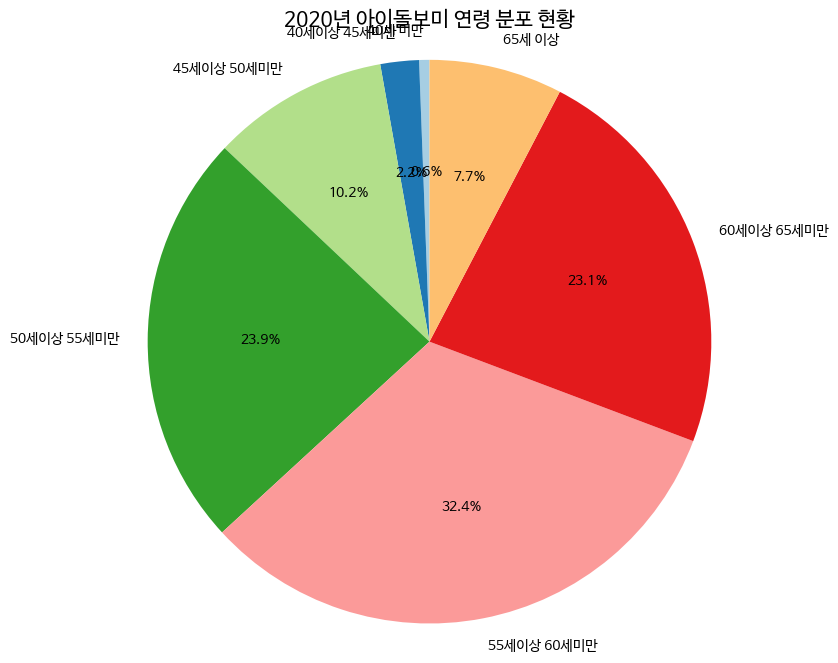

In [41]:
# 연령대와 인원수를 각각 변수에 할당
labels = df_childcare_age['연령대']
sizes = df_childcare_age['인원수(명)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2020년 아이돌보미 연령 분포 현황', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

## 아이돌보미의 인구학적 특성

### 아이돌보미의 자녀 양육 경험

#### 자녀 유무

In [47]:
# 데이터 생성
data = {
    '자녀유무': ['자녀 있음', '자녀 없음'],
    '인원수(명)': [5970, 141]
}

# DataFrame으로 변환
df_childcare_child = pd.DataFrame(data)
df_childcare_child

,자녀유무,인원수(명)
0,자녀 있음,5970
1,자녀 없음,141


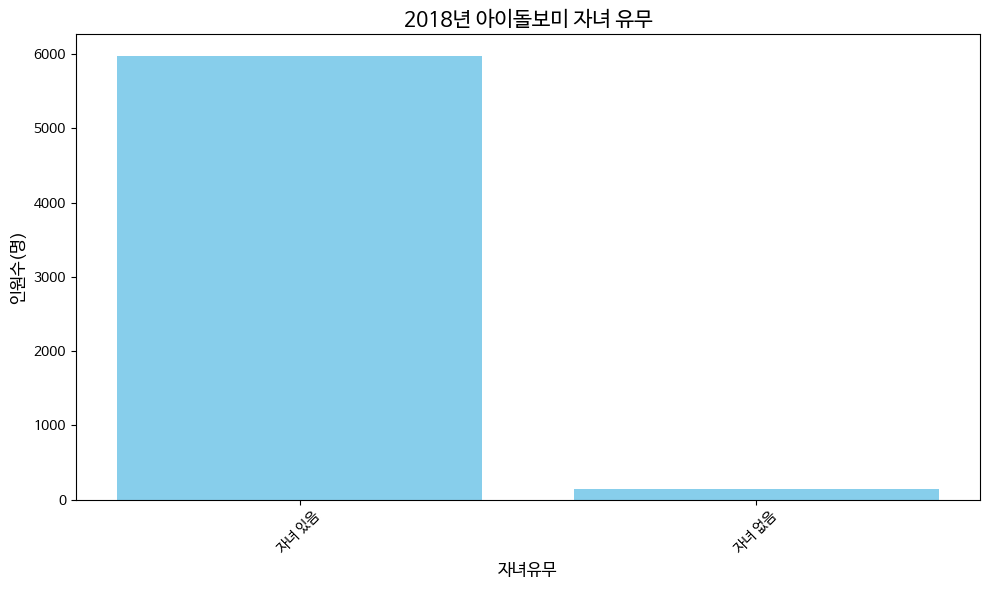

In [50]:
# 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(df_childcare_child['자녀유무'], df_childcare_child['인원수(명)'], color='skyblue')

# 그래프 제목 및 라벨 추가
plt.title('2018년 아이돌보미 자녀 유무', fontsize=15)
plt.xlabel('자녀유무', fontsize=12)
plt.ylabel('인원수(명)', fontsize=12)

# 그래프 보여주기
plt.xticks(rotation=45)  # x축 레이블 회전
plt.tight_layout()  # 레이아웃 조정
plt.show()

#### 막내자녀 연령

In [51]:
# 데이터 생성
data = {
    '막내자녀 연령': ['18세 미만', '18-25세 미만', '25세-30세 미만', '30-35세 미만', '35세 이상', '모름/무응답'],
    '인원수(명)': [626, 1258, 2156, 1535, 529, 7]
}


# DataFrame으로 변환
df_childcare_childage = pd.DataFrame(data)
df_childcare_childage

,막내자녀 연령,인원수(명)
0,18세 미만,626
1,18-25세 미만,1258
2,25세-30세 미만,2156
3,30-35세 미만,1535
4,35세 이상,529
5,모름/무응답,7


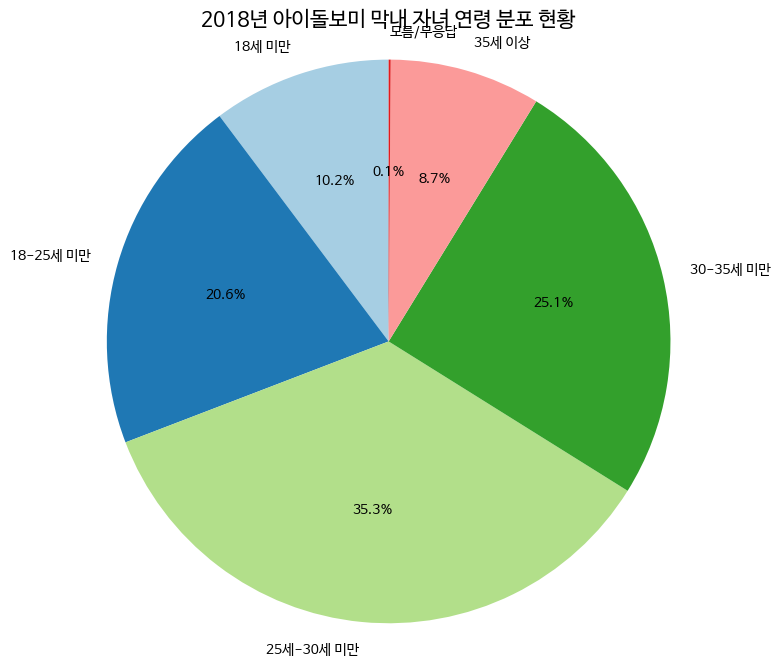

In [52]:
# 연령대와 인원수를 각각 변수에 할당
labels = df_childcare_childage['막내자녀 연령']
sizes = df_childcare_childage['인원수(명)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2018년 아이돌보미 막내 자녀 연령 분포 현황', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

#### 총 자녀수

In [53]:
# 데이터 생성
data = {
    '총자녀수': ['1명', '2명', '3명 이상', '모름/무응답'],
    '인원수(명)': [847, 4191, 910, 20]
}

# DataFrame으로 변환
df_childcare_totalchild = pd.DataFrame(data)
df_childcare_totalchild

,총자녀수,인원수(명)
0,1명,847
1,2명,4191
2,3명 이상,910
3,모름/무응답,20


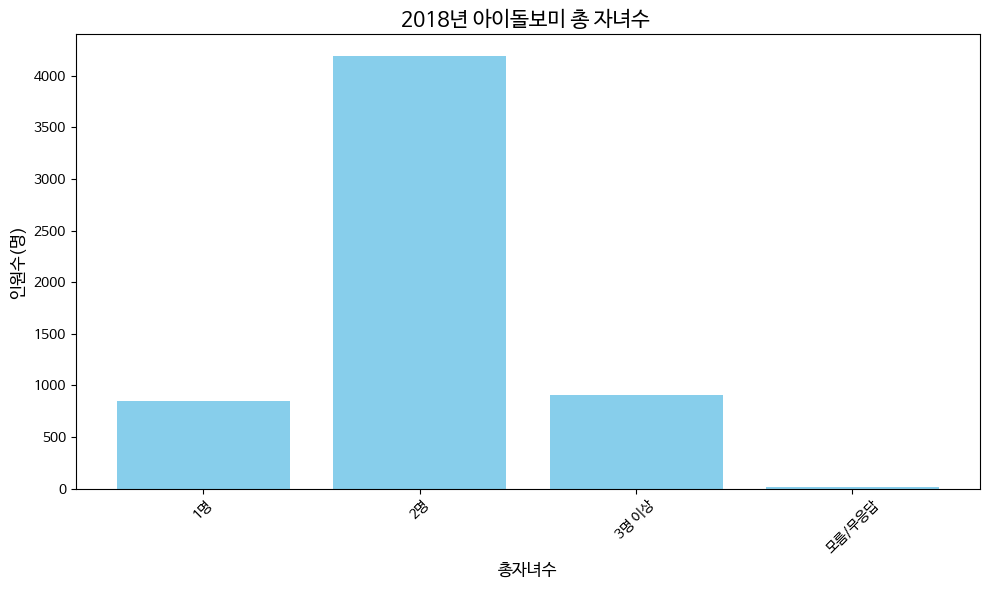

In [54]:
# 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(df_childcare_totalchild['총자녀수'], df_childcare_totalchild['인원수(명)'], color='skyblue')

# 그래프 제목 및 라벨 추가
plt.title('2018년 아이돌보미 총 자녀수 ', fontsize=15)
plt.xlabel('총자녀수', fontsize=12)
plt.ylabel('인원수(명)', fontsize=12)

# 그래프 보여주기
plt.xticks(rotation=45)  # x축 레이블 회전
plt.tight_layout()  # 레이아웃 조정
plt.show()

#### 아이돌보미 건강상태

In [55]:
# 데이터 생성
data = {
    '건강상태': ['중한 질병/장애 있음', '경미한 질병/장애 있음', '건강한 편임', '매우 건강함'],
    '인원수(명)': [10, 421, 4020, 1660]
}

# DataFrame으로 변환
df_childcare_health = pd.DataFrame(data)
df_childcare_health

,건강상태,인원수(명)
0,중한 질병/장애 있음,10
1,경미한 질병/장애 있음,421
2,건강한 편임,4020
3,매우 건강함,1660


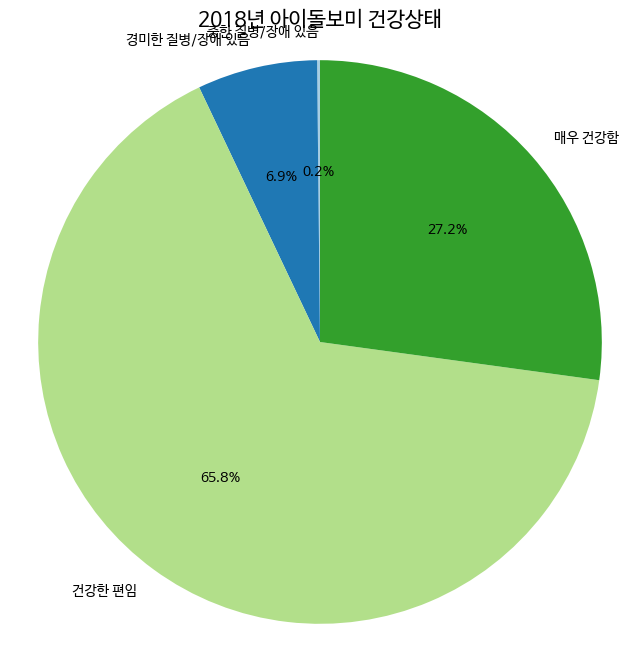

In [56]:
# 연령대와 인원수를 각각 변수에 할당
labels = df_childcare_health['건강상태']
sizes = df_childcare_health['인원수(명)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2018년 아이돌보미 건강상태', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

## 아이돌보미의 학력 및 전공

### 아이돌보미의 최종 학력

In [57]:
# 데이터 생성
data = {
    '최종 학력': ['중학교 졸업 이하', '고등학교 졸업', '2-3년제 대학 졸업', '4년제 대학 졸업 이상'],
    '인원수(명)': [614, 3440, 1066, 991]
}

# DataFrame으로 변환
df_childcare_guraduration = pd.DataFrame(data)
df_childcare_guraduration

,최종 학력,인원수(명)
0,중학교 졸업 이하,614
1,고등학교 졸업,3440
2,2-3년제 대학 졸업,1066
3,4년제 대학 졸업 이상,991


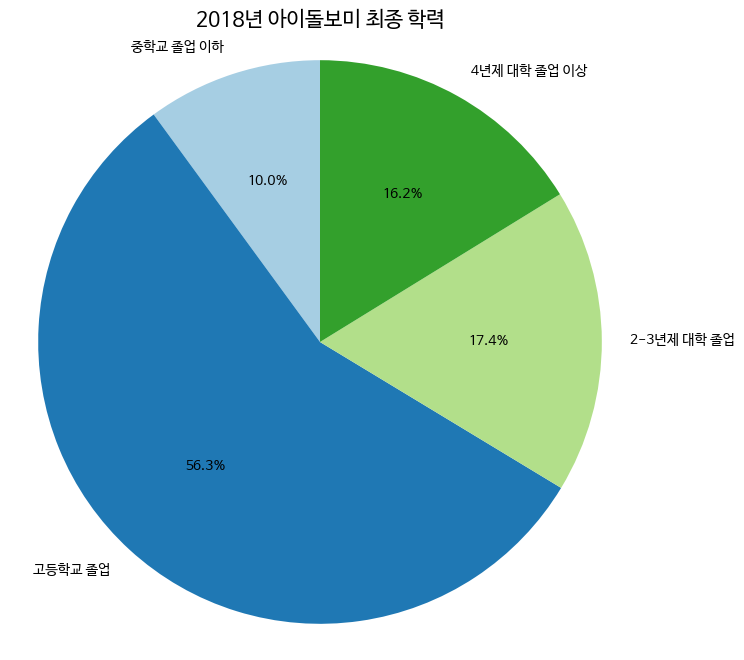

In [58]:
# 연령대와 인원수를 각각 변수에 할당
labels = df_childcare_guraduration['최종 학력']
sizes = df_childcare_guraduration['인원수(명)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2018년 아이돌보미 최종 학력', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

### 아이돌보미의 최종 학력

In [59]:
# 데이터 생성
data = {
    '대학졸업자의 전공': ['사회복지학', '교육/보육 관련 전공', '영양학', '간호학', '기타'],
    '인원수(명)': [337, 915, 78, 19, 706]
}

# DataFrame으로 변환
df_childcare_major = pd.DataFrame(data)
df_childcare_major

,대학졸업자의 전공,인원수(명)
0,사회복지학,337
1,교육/보육 관련 전공,915
2,영양학,78
3,간호학,19
4,기타,706


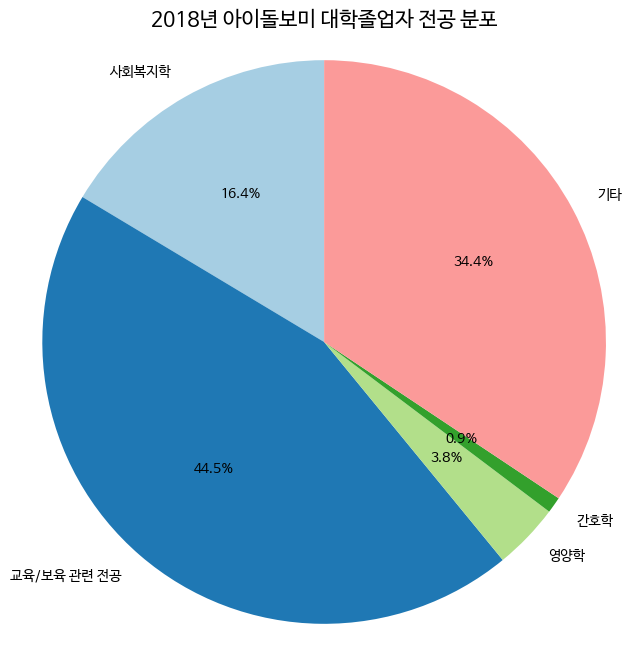

In [60]:
# 연령대와 인원수를 각각 변수에 할당
labels = df_childcare_major['대학졸업자의 전공']
sizes = df_childcare_major['인원수(명)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2018년 아이돌보미 대학졸업자 전공 분포', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

## 아이돌보미의 자격증

### 아이돌보미의 자격증 보유 여부

In [61]:
# 데이터 생성
data = {
    '자격증 보유 여부': ['자격증 있음', '자격증 없음'],
    '응답비율(%)': [63.5, 36.5]
}

# DataFrame으로 변환
df_childcare_certification = pd.DataFrame(data)
df_childcare_certification

,자격증 보유 여부,응답비율(%)
0,자격증 있음,63.5
1,자격증 없음,36.5


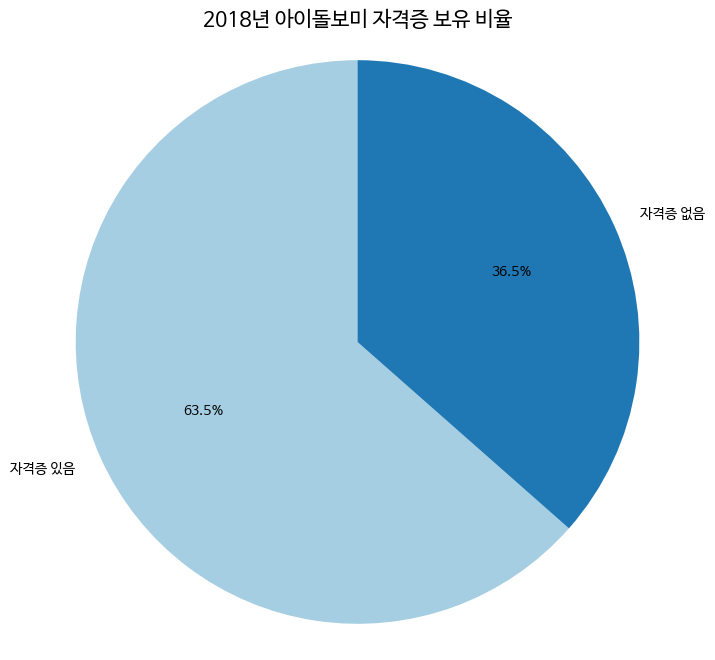

In [62]:
# 연령대와 인원수를 각각 변수에 할당
labels = df_childcare_certification['자격증 보유 여부']
sizes = df_childcare_certification['응답비율(%)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2018년 아이돌보미 자격증 보유 비율', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

### 아이돌보미의 보유 자격증 종류 분포

In [64]:
# 데이터 생성
data = {
    '보유 자격증': ['관련 자격증 없음', '어린이집 교사 자격증', '조리사 자격증', '사회복지사 자격증', '어린이집 원장 자격증', '유치원 교사 자격증', '간호사 자격증', '치료사 자격증', '영양사 자격증', '초등교사 자격증', '특수교사 자격증', '유치원 원장 자격증'],
    '응답비율(%)': [63.5, 16.7, 13.4, 12.3, 4.4, 4.1, 1.7, 1.6, 1.1, 1.1, 0.8, 0.3]
}

# DataFrame으로 변환
df_childcare_certification_kind = pd.DataFrame(data)
df_childcare_certification_kind

,보유 자격증,응답비율(%)
0,관련 자격증 없음,63.5
1,어린이집 교사 자격증,16.7
2,조리사 자격증,13.4
3,사회복지사 자격증,12.3
4,어린이집 원장 자격증,4.4
5,유치원 교사 자격증,4.1
6,간호사 자격증,1.7
7,치료사 자격증,1.6
8,영양사 자격증,1.1
9,초등교사 자격증,1.1


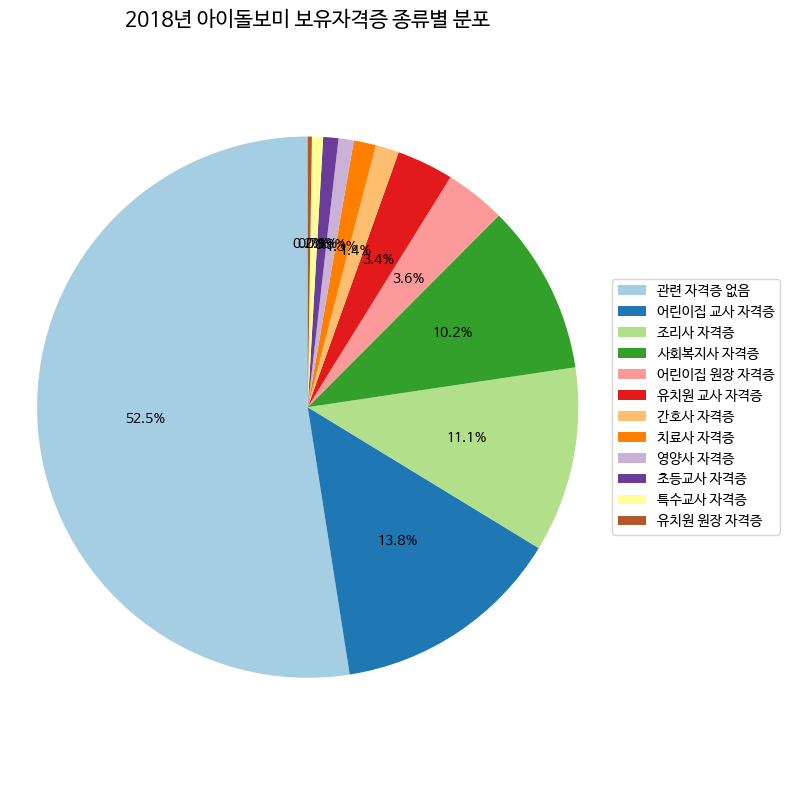

In [66]:
# 라벨과 비율을 변수에 할당
labels = df_childcare_certification_kind['보유 자격증']
sizes = df_childcare_certification_kind['응답비율(%)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(
    sizes, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors
)

# 범례 추가
plt.legend(patches, labels, loc="center left", bbox_to_anchor=(1, 0.5))

# 그래프 제목 추가
plt.title('2018년 아이돌보미 보유자격증 종류별 분포', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.tight_layout()  # 레이아웃 조정
plt.show()

## 아이돌보미 활동 관련 특성

### 아이돌보미 활동 유형별 분포 현황

In [67]:
# 데이터 생성
data = {
    '활동 유형': ['시간제 서비스', '종일제 서비스', '특별 서비스'],
    '인원수(명)': [5135, 922, 54]
}

# DataFrame으로 변환
df_childcare_activity = pd.DataFrame(data)
df_childcare_activity

,활동 유형,인원수(명)
0,시간제 서비스,5135
1,종일제 서비스,922
2,특별 서비스,54


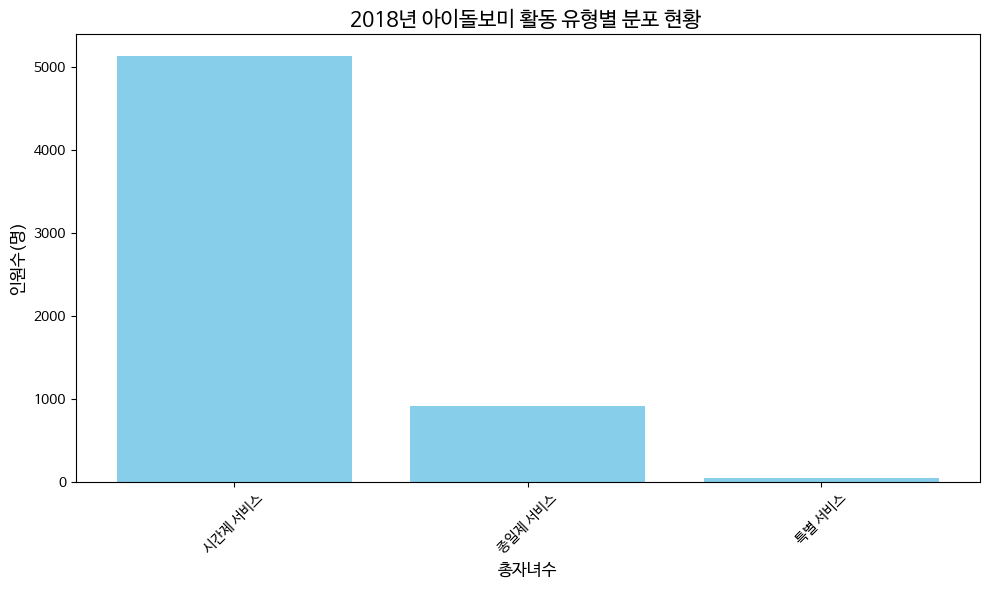

In [68]:
# 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(df_childcare_activity['활동 유형'], df_childcare_activity['인원수(명)'], color='skyblue')

# 그래프 제목 및 라벨 추가
plt.title('2018년 아이돌보미 활동 유형별 분포 현황 ', fontsize=15)
plt.xlabel('총자녀수', fontsize=12)
plt.ylabel('인원수(명)', fontsize=12)

# 그래프 보여주기
plt.xticks(rotation=45)  # x축 레이블 회전
plt.tight_layout()  # 레이아웃 조정
plt.show()

### 아이돌보미 활동 경력 

In [69]:
# 데이터 생성
data = {
    '활동 경력': ['1년 미만', '1년이상 3년미만', '3년이상 5년미만', '5년이상 7년미만', '7년 이상'],
    '인원수(명)': [624, 1316, 1270 ,1368, 1533]
}

# DataFrame으로 변환
df_childcare_career = pd.DataFrame(data)
df_childcare_career

,활동 경력,인원수(명)
0,1년 미만,624
1,1년이상 3년미만,1316
2,3년이상 5년미만,1270
3,5년이상 7년미만,1368
4,7년 이상,1533


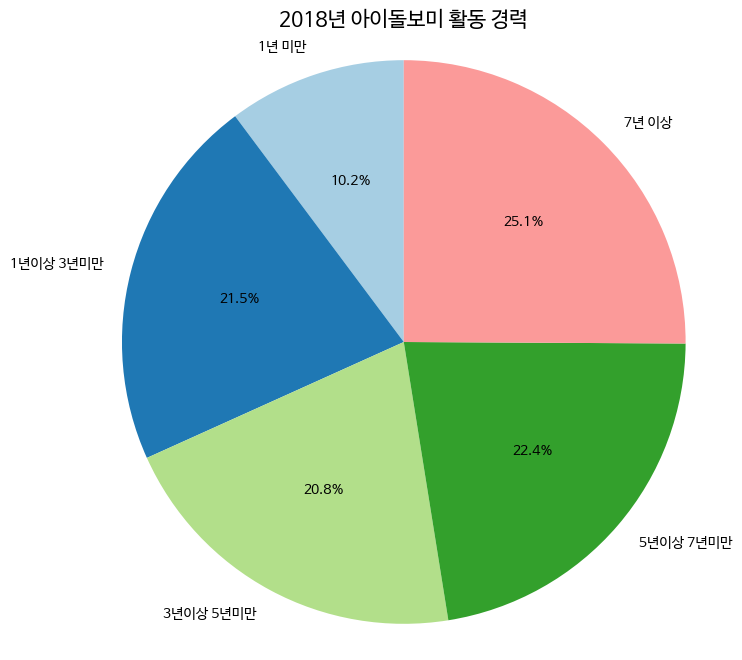

In [70]:
# 각각 변수에 할당
labels = df_childcare_career['활동 경력']
sizes = df_childcare_career['인원수(명)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2018년 아이돌보미 활동 경력', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

## 아이돌보미 경제적 특성 및 활동소득 만족도

### 아이돌보미 가구 소득

In [74]:
# 데이터 생성
data = {
    '월 평균 가구소득': ['200만원 미만', '200만원 이상 300만원 미만', '300만원 이상 400만원 미만', '400만원 이상 500만원 미만', '500만원 이상'],
    '인원수(명)': [1637, 1822, 1171, 771, 710]
}

# DataFrame으로 변환
df_childcare_income_total = pd.DataFrame(data)
df_childcare_income_total

,월 평균 가구소득,인원수(명)
0,200만원 미만,1637
1,200만원 이상 300만원 미만,1822
2,300만원 이상 400만원 미만,1171
3,400만원 이상 500만원 미만,771
4,500만원 이상,710


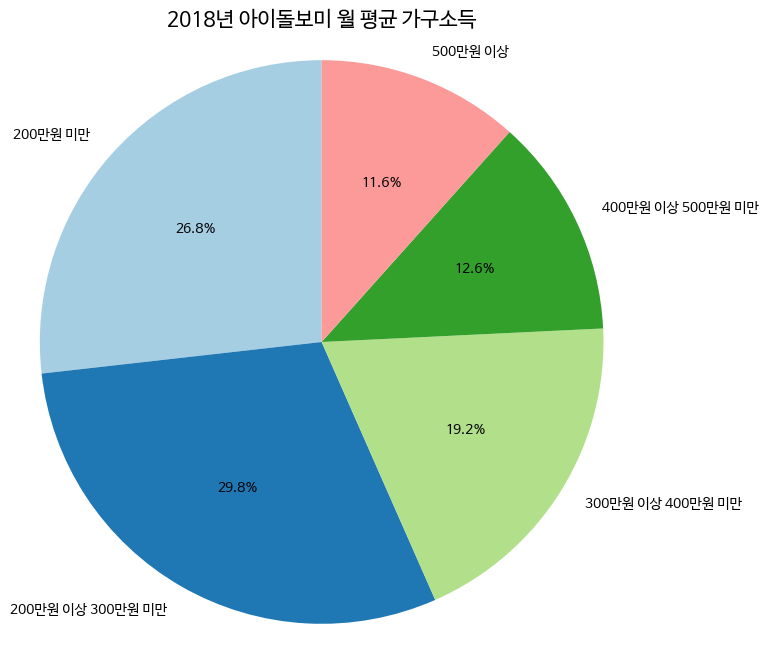

In [75]:
# 각각 변수에 할당
labels = df_childcare_income_total['월 평균 가구소득']
sizes = df_childcare_income_total['인원수(명)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2018년 아이돌보미 월 평균 가구소득', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

### 아이돌보미 활동 소득

In [78]:
# 데이터 생성
data = {
    '활동소득': ['50만원 미만', '50만원이상 80만원미만', '80만원이상 100만원미만', '100만원이상 120만원미만', '120만원이상 150만원미만', '150만원이상 180만원미만', '180만원 이상'],
    '비율(%)': [21, 28.1, 18.9, 13.1, 9.4, 5.5, 4.1]
}

# DataFrame으로 변환
df_childcare_income = pd.DataFrame(data)
df_childcare_income

,활동소득,비율(%)
0,50만원 미만,21.0
1,50만원이상 80만원미만,28.1
2,80만원이상 100만원미만,18.9
3,100만원이상 120만원미만,13.1
4,120만원이상 150만원미만,9.4
5,150만원이상 180만원미만,5.5
6,180만원 이상,4.1


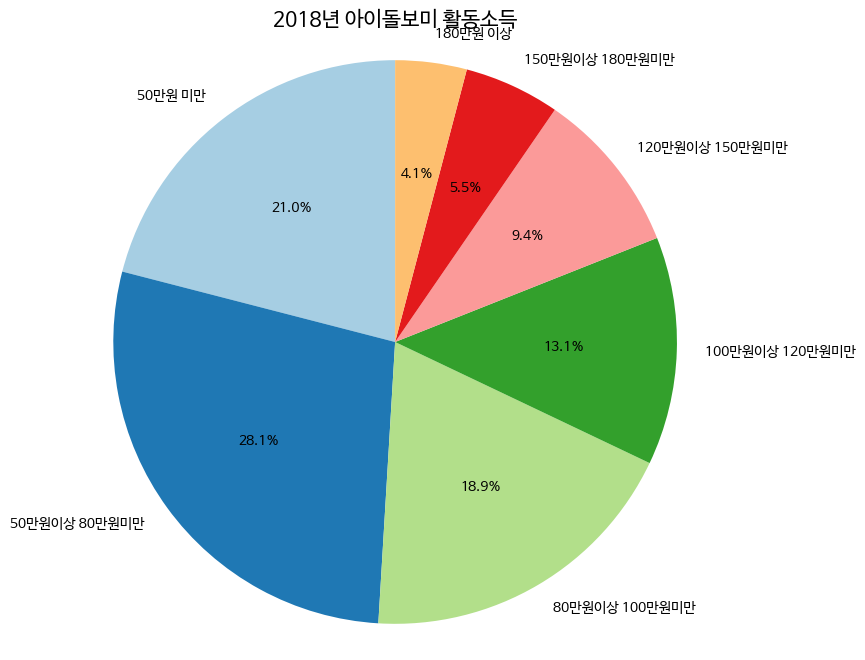

In [81]:
# 각각 변수에 할당
labels = df_childcare_income['활동소득']
sizes = df_childcare_income['비율(%)']

# 파이차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# 그래프 제목 추가
plt.title('2018년 아이돌보미 활동소득', fontsize=15)

# 파이차트가 원형으로 보이도록 설정
plt.axis('equal')

# 그래프 보여주기
plt.show()

### 특성별 아이돌보미의 활동 소득

#### 아이돌보미 활동 유형별

In [84]:
# 데이터 생성
data = {
    '구분': ['시간제 서비스', '종일제 서비스', '특별 서비스'],
    '50만원 미만': [23.6, 5.0, 38.9],
    '50만원 이상~80만원 미만': [32.1, 5.9, 27.8],
    '80만원 이상~100만원 미만': [20.1, 12.0, 16.7],
    '100만원 이상~120만원 미만': [12.0, 19.1, 11.1],
    '120만원 이상~150만원 미만': [6.7, 24.7, 1.9],
    '150만원 이상~180만원 미만': [3.0, 19.4, 3.7],
    '180만원 이상': [2.4, 13.9, 0.0]
}

# DataFrame으로 변환
df_childcare_activity_income = pd.DataFrame(data)
df_childcare_activity_income

,구분,50만원 미만,50만원 이상~80만원 미만,80만원 이상~100만원 미만,100만원 이상~120만원 미만,120만원 이상~150만원 미만,150만원 이상~180만원 미만,180만원 이상
0,시간제 서비스,23.6,32.1,20.1,12.0,6.7,3.0,2.4
1,종일제 서비스,5.0,5.9,12.0,19.1,24.7,19.4,13.9
2,특별 서비스,38.9,27.8,16.7,11.1,1.9,3.7,0.0


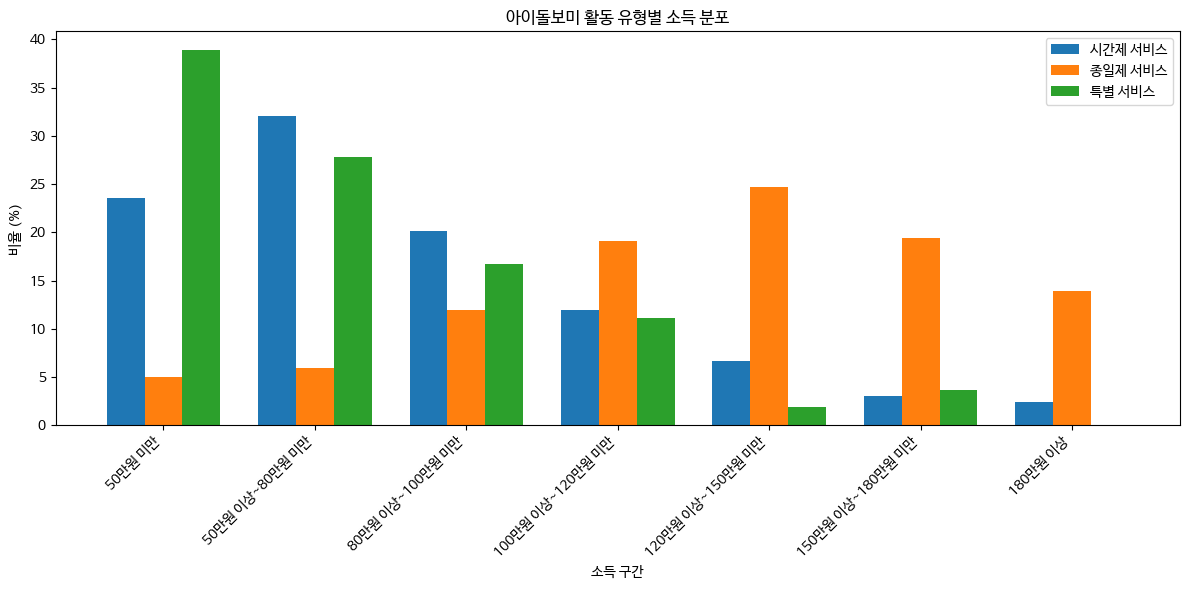

In [89]:
# 그래프 설정
fig, ax = plt.subplots(figsize=(12, 6))

# 막대 그래프 그리기
bar_width = 0.25
index = range(len(df_childcare_activity_income.columns[1:]))

for i, service in enumerate(df_childcare_activity_income['구분']):
    ax.bar([x + i*bar_width for x in index], df_childcare_activity_income.iloc[i, 1:], 
           width=bar_width, label=service)

# 그래프 꾸미기
ax.set_xlabel('소득 구간')
ax.set_ylabel('비율 (%)')
ax.set_title('아이돌보미 활동 유형별 소득 분포')
ax.set_xticks([x + bar_width for x in index])
ax.set_xticklabels(df_childcare_activity_income.columns[1:], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_22/785047389.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_childcare_activity_income.columns[1:], rotation=45, ha='right')
/tmp/ipykernel_22/785047389.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_childcare_activity_income.columns[1:], rotation=45, ha='right')
/tmp/ipykernel_22/785047389.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_childcare_activity_income.columns[1:], rotation=45, ha='right')


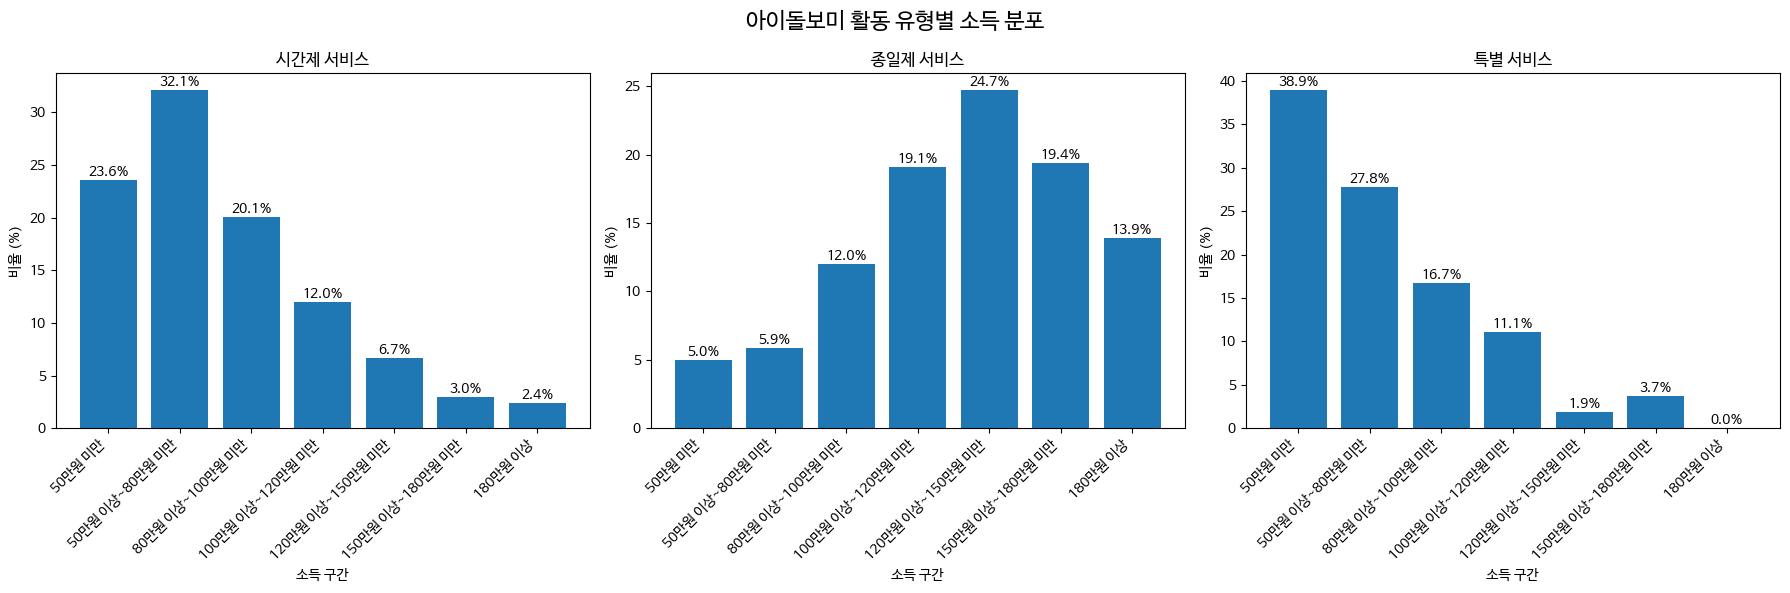

In [90]:
# 그래프 설정
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('아이돌보미 활동 유형별 소득 분포', fontsize=16)

# 각 서비스 유형별로 그래프 그리기
for i, service in enumerate(df_childcare_activity_income['구분']):
    ax = axes[i]
    values = df_childcare_activity_income.iloc[i, 1:]
    ax.bar(df_childcare_activity_income.columns[1:], values)
    ax.set_title(service)
    ax.set_xlabel('소득 구간')
    ax.set_ylabel('비율 (%)')
    ax.set_xticklabels(df_childcare_activity_income.columns[1:], rotation=45, ha='right')
    
    # 각 막대 위에 값 표시
    for j, v in enumerate(values):
        ax.text(j, v, f'{v}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### 아이돌보미 활동 경력별

In [91]:
# DataFrame 생성
data = {
    '활동 경력': ['1년 미만', '1년 이상 3년 미만', '3년 이상 5년 미만', '5년 이상 7년 미만', '7년 이상'],
    '50만원 미만': [38.3, 25.9, 19.3, 17.2, 14.4],
    '50만원 이상~80만원 미만': [32.1, 30.9, 26.1, 28.7, 25.3],
    '80만원 이상~100만원 미만': [14.1, 16.6, 19.1, 19.4, 22.0],
    '100만원 이상~120만원 미만': [6.7, 11.2, 15.7, 13.6, 14.7],
    '120만원 이상~150만원 미만': [5.6, 7.9, 9.9, 11.0, 10.3],
    '150만원 이상~180만원 미만': [2.4, 4.6, 6.2, 5.5, 7.0],
    '180만원 이상': [0.8, 3.0, 3.7, 4.6, 6.2],
    '계(수)': ['100.0( 624)', '100.0(1,316)', '100.0(1,270)', '100.0(1,368)', '100.0(1,533)']
}

df_childcare_career_income = pd.DataFrame(data)
df_childcare_career_income

,활동 경력,50만원 미만,50만원 이상~80만원 미만,80만원 이상~100만원 미만,100만원 이상~120만원 미만,120만원 이상~150만원 미만,150만원 이상~180만원 미만,180만원 이상,계(수)
0,1년 미만,38.3,32.1,14.1,6.7,5.6,2.4,0.8,100.0( 624)
1,1년 이상 3년 미만,25.9,30.9,16.6,11.2,7.9,4.6,3.0,"100.0(1,316)"
2,3년 이상 5년 미만,19.3,26.1,19.1,15.7,9.9,6.2,3.7,"100.0(1,270)"
3,5년 이상 7년 미만,17.2,28.7,19.4,13.6,11.0,5.5,4.6,"100.0(1,368)"
4,7년 이상,14.4,25.3,22.0,14.7,10.3,7.0,6.2,"100.0(1,533)"


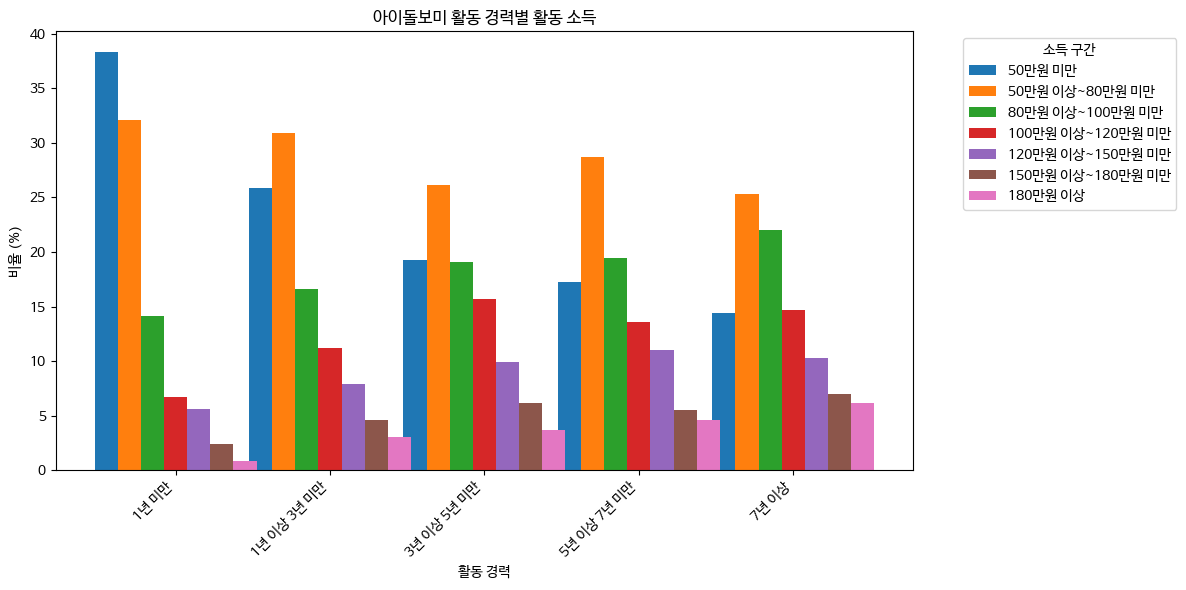

In [93]:
# 시각화
plt.figure(figsize=(12, 6))

# 각 경력 구간에 대해 막대 그래프 생성
bar_width = 0.15
index = range(len(df_childcare_career_income['활동 경력']))

for i, column in enumerate(df_childcare_career_income.columns[1:-1]):  # '계(수)' 열 제외
    plt.bar([x + i * bar_width for x in index], df_childcare_career_income[column], 
            width=bar_width, label=column)

plt.xlabel('활동 경력')
plt.ylabel('비율 (%)')
plt.title('아이돌보미 활동 경력별 활동 소득')
plt.xticks([x + 3 * bar_width for x in index], df_childcare_career_income['활동 경력'], rotation=45, ha='right')
plt.legend(title='소득 구간', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 아이돌보미 최종 학력별

In [94]:
# DataFrame 생성
data = {
    '최종 학력': ['중학교 졸업 이하', '고등학교 졸업', '2~3년제 대학 졸업', '4년제 대학 졸업 이상'],
    '50만원 미만': [17.4, 19.5, 26.0, 22.7],
    '50만원 이상~80만원 미만': [29.0, 28.4, 25.5, 29.3],
    '80만원 이상~100만원 미만': [18.2, 19.2, 17.4, 19.7],
    '100만원 이상~120만원 미만': [13.8, 13.8, 11.9, 11.6],
    '120만원 이상~150만원 미만': [11.7, 9.1, 9.2, 9.3],
    '150만원 이상~180만원 미만': [5.7, 5.8, 5.5, 4.3],
    '180만원 이상': [4.1, 4.2, 4.5, 3.1],
    '계(수)': ['100.0( 614)', '100.0(3,440)', '100.0(1,066)', '100.0( 991)']
}

df_childcare_graduration_income = pd.DataFrame(data)
df_childcare_graduration_income

,최종 학력,50만원 미만,50만원 이상~80만원 미만,80만원 이상~100만원 미만,100만원 이상~120만원 미만,120만원 이상~150만원 미만,150만원 이상~180만원 미만,180만원 이상,계(수)
0,중학교 졸업 이하,17.4,29.0,18.2,13.8,11.7,5.7,4.1,100.0( 614)
1,고등학교 졸업,19.5,28.4,19.2,13.8,9.1,5.8,4.2,"100.0(3,440)"
2,2~3년제 대학 졸업,26.0,25.5,17.4,11.9,9.2,5.5,4.5,"100.0(1,066)"
3,4년제 대학 졸업 이상,22.7,29.3,19.7,11.6,9.3,4.3,3.1,100.0( 991)


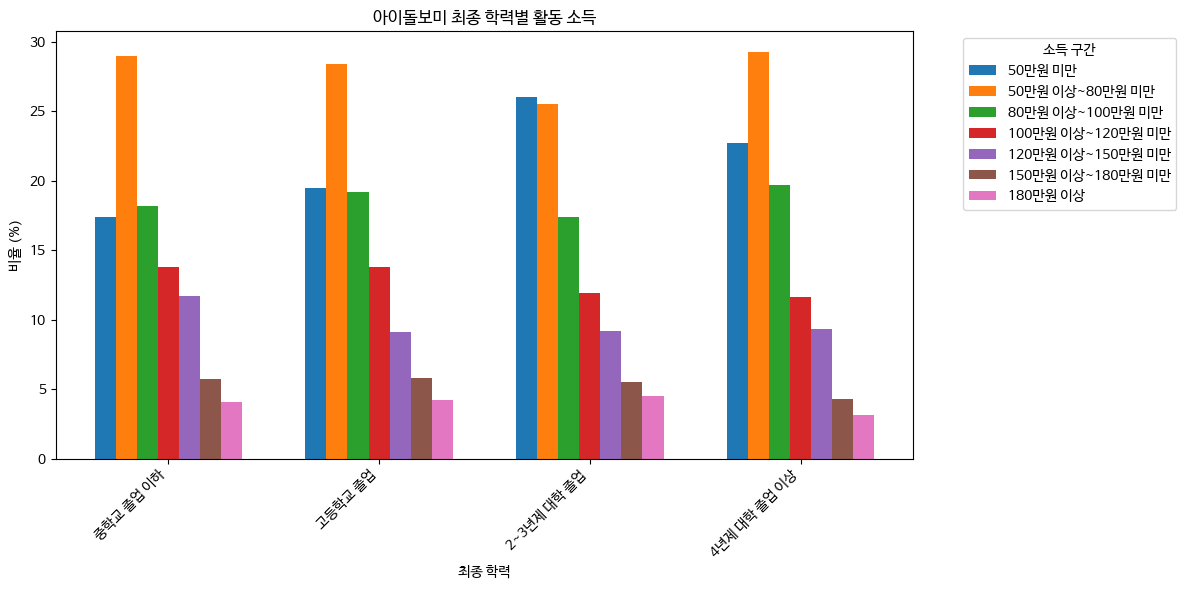

In [95]:
# 시각화
plt.figure(figsize=(12, 6))

# 각 학력 구간에 대해 막대 그래프 생성
bar_width = 0.1
index = range(len(df_childcare_graduration_income['최종 학력']))

for i, column in enumerate(df_childcare_graduration_income.columns[1:-1]):  # '계(수)' 열 제외
    plt.bar([x + i * bar_width for x in index], df_childcare_graduration_income[column], 
            width=bar_width, label=column)

plt.xlabel('최종 학력')
plt.ylabel('비율 (%)')
plt.title('아이돌보미 최종 학력별 활동 소득')
plt.xticks([x + 3 * bar_width for x in index], df_childcare_graduration_income['최종 학력'], rotation=45, ha='right')
plt.legend(title='소득 구간', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 특성별 아이돌보미 활동 소득 만족도

In [96]:
# DataFrame 생성
satisfaction_df = pd.DataFrame({
    '만족도 수준': ['전혀 만족하지 못함', '별로 만족하지 못함', '만족함', '매우 만족함'],
    '비율': [17.6, 52.2, 28.4, 1.9],
    '점수': [1, 2, 3, 4]
})

satisfaction_df

,만족도 수준,비율,점수
0,전혀 만족하지 못함,17.6,1
1,별로 만족하지 못함,52.2,2
2,만족함,28.4,3
3,매우 만족함,1.9,4


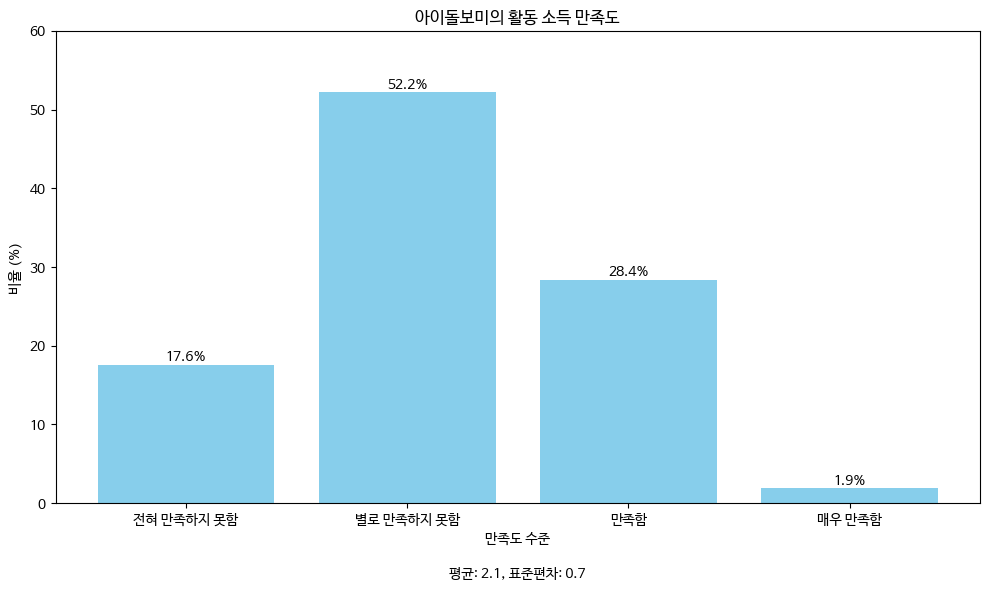

In [97]:
# 시각화
plt.figure(figsize=(10, 6))

# 막대 그래프
bars = plt.bar(satisfaction_df['만족도 수준'], satisfaction_df['비율'], color='skyblue')

# 막대 위에 비율 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}%', ha='center', va='bottom')

plt.title('아이돌보미의 활동 소득 만족도')
plt.xlabel('만족도 수준')
plt.ylabel('비율 (%)')

# y축 범위 설정
plt.ylim(0, 60)

# 평균과 표준편차 정보 추가
plt.text(0.5, -0.15, '평균: 2.1, 표준편차: 0.7', ha='center', va='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

### 아이돌보미 활동 유형별

In [98]:
# DataFrame 생성
activity_satisfaction_df = pd.DataFrame({
    '활동 유형': ['시간제 서비스', '종일제 서비스', '특별 서비스'],
    '전혀 만족하지 못함': [18.7, 11.2, 22.2],
    '별로 만족하지 못함': [53.0, 47.6, 50.0],
    '만족함': [26.8, 37.3, 24.1],
    '매우 만족함': [1.5, 3.9, 3.7],
    '평균': [2.1, 2.3, 2.1],
    '표준편차': [0.7, 0.7, 0.8],
    '계(수)': ['100.0(5,135)', '100.0( 922)', '100.0( 54)']
})

activity_satisfaction_df

,활동 유형,전혀 만족하지 못함,별로 만족하지 못함,만족함,매우 만족함,평균,표준편차,계(수)
0,시간제 서비스,18.7,53.0,26.8,1.5,2.1,0.7,"100.0(5,135)"
1,종일제 서비스,11.2,47.6,37.3,3.9,2.3,0.7,100.0( 922)
2,특별 서비스,22.2,50.0,24.1,3.7,2.1,0.8,100.0( 54)


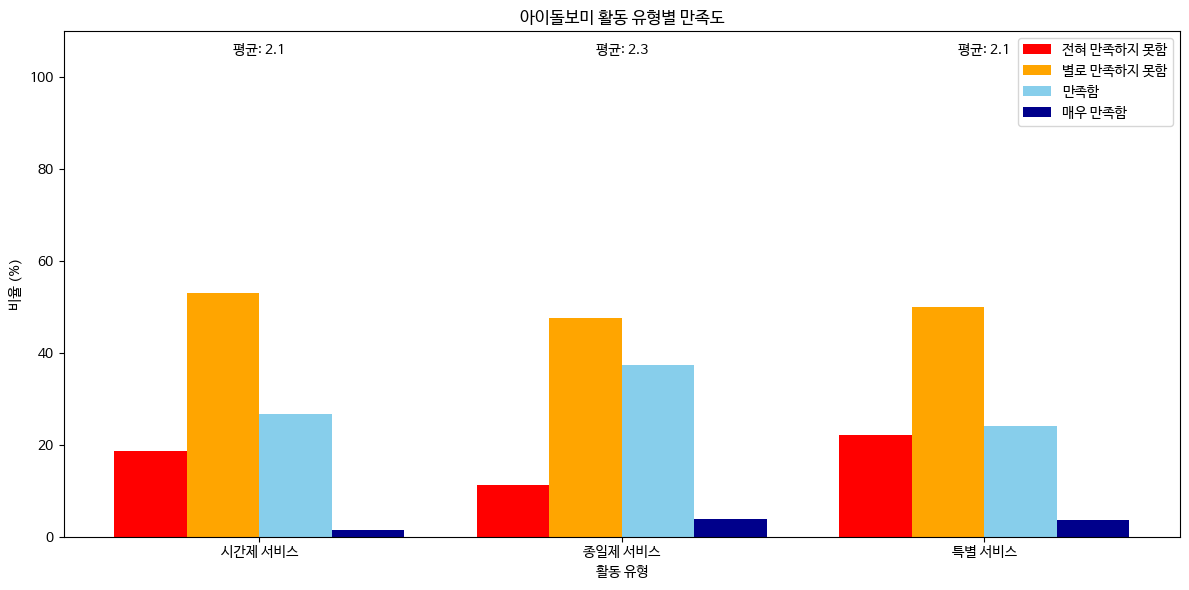

In [100]:
# 시각화
plt.figure(figsize=(12, 6))

# 막대 그래프 생성
bar_width = 0.2
index = range(len(activity_satisfaction_df['활동 유형']))

plt.bar(index, activity_satisfaction_df['전혀 만족하지 못함'], bar_width, label='전혀 만족하지 못함', color='red')
plt.bar([i + bar_width for i in index], activity_satisfaction_df['별로 만족하지 못함'], bar_width, label='별로 만족하지 못함', color='orange')
plt.bar([i + 2 * bar_width for i in index], activity_satisfaction_df['만족함'], bar_width, label='만족함', color='skyblue')
plt.bar([i + 3 * bar_width for i in index], activity_satisfaction_df['매우 만족함'], bar_width, label='매우 만족함', color='darkblue')

plt.xlabel('활동 유형')
plt.ylabel('비율 (%)')
plt.title('아이돌보미 활동 유형별 만족도')
plt.xticks([i + 1.5 * bar_width for i in index], activity_satisfaction_df['활동 유형'])
plt.legend()

# 평균 점수 표시
for i, avg in enumerate(activity_satisfaction_df['평균']):
    plt.text(i + 1.5 * bar_width, 105, f'평균: {avg}', ha='center')

plt.ylim(0, 110)  # y축 범위 설정

plt.tight_layout()
plt.show()

### 아이돌보미 활동 경력별

In [111]:
# DataFrame 생성
career_satisfaction_df = pd.DataFrame({
    '활동 경력': ['1년 미만', '1년 이상 3년 미만', '3년 이상 5년 미만', '5년 이상 7년 미만', '7년 이상'],
    '전혀 만족하지 못함': [23.7, 19.1, 16.6, 15.5, 16.3],
    '별로 만족하지 못함': [52.2, 54.3, 51.7, 51.4, 51.3],
    '만족함': [22.9, 24.8, 30.2, 31.0, 29.7],
    '매우 만족함': [1.1, 1.7, 1.4, 2.1, 2.7],
    '평균': [2.0, 2.1, 2.2, 2.2, 2.2],
    '표준편차': [0.7, 0.7, 0.7, 0.7, 0.7],
    '계(수)': ['100.0( 624)', '100.0(1,316)', '100.0(1,270)', '100.0(1,368)', '100.0(1,533)']
})

career_satisfaction_df

,활동 경력,전혀 만족하지 못함,별로 만족하지 못함,만족함,매우 만족함,평균,표준편차,계(수)
0,1년 미만,23.7,52.2,22.9,1.1,2.0,0.7,100.0( 624)
1,1년 이상 3년 미만,19.1,54.3,24.8,1.7,2.1,0.7,"100.0(1,316)"
2,3년 이상 5년 미만,16.6,51.7,30.2,1.4,2.2,0.7,"100.0(1,270)"
3,5년 이상 7년 미만,15.5,51.4,31.0,2.1,2.2,0.7,"100.0(1,368)"
4,7년 이상,16.3,51.3,29.7,2.7,2.2,0.7,"100.0(1,533)"


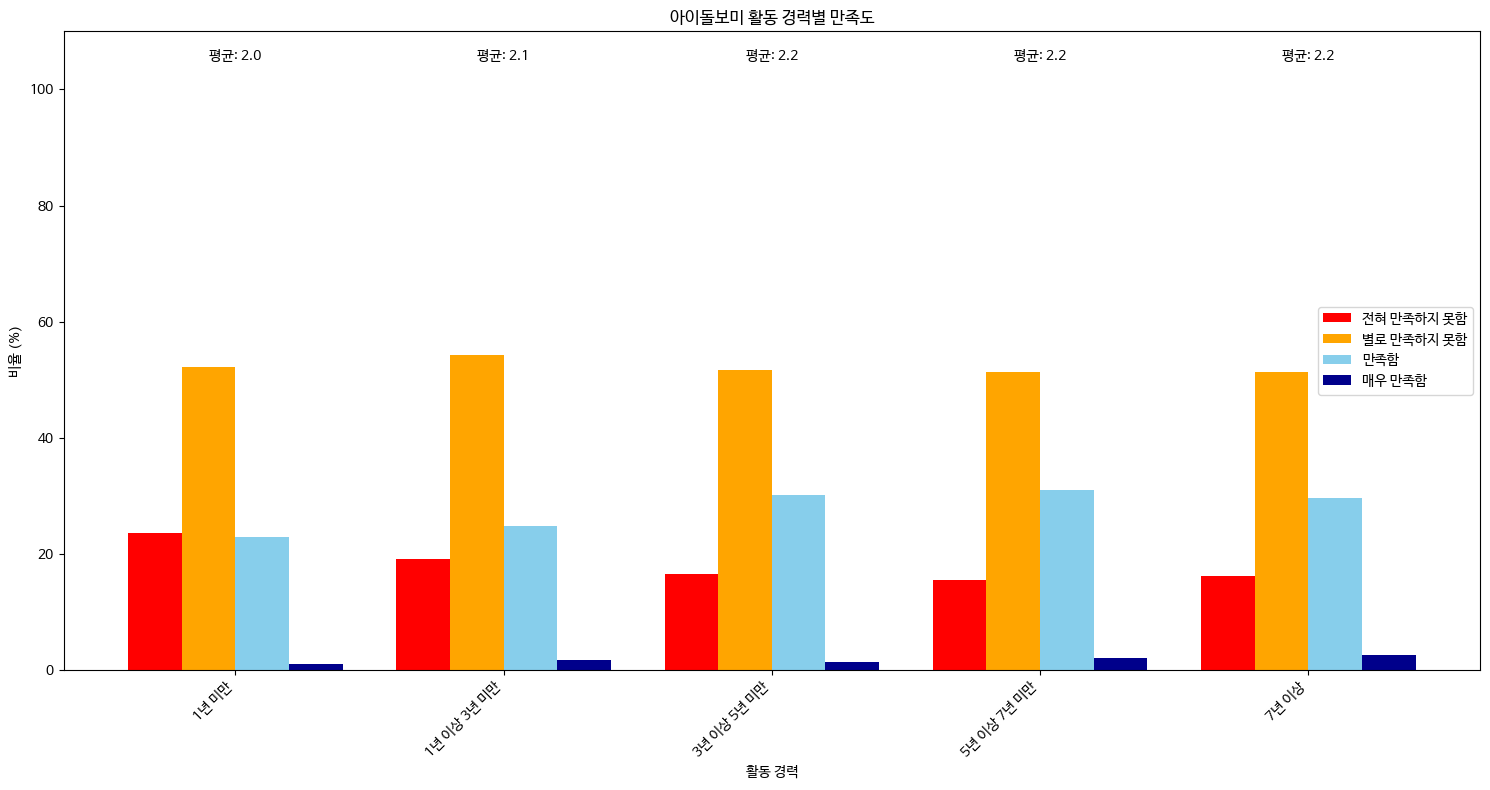

In [112]:
# 시각화
plt.figure(figsize=(15, 8))

# 막대 그래프 생성
bar_width = 0.2
index = range(len(career_satisfaction_df['활동 경력']))

plt.bar(index, career_satisfaction_df['전혀 만족하지 못함'], bar_width, label='전혀 만족하지 못함', color='red')
plt.bar([i + bar_width for i in index], career_satisfaction_df['별로 만족하지 못함'], bar_width, label='별로 만족하지 못함', color='orange')
plt.bar([i + 2 * bar_width for i in index], career_satisfaction_df['만족함'], bar_width, label='만족함', color='skyblue')
plt.bar([i + 3 * bar_width for i in index], career_satisfaction_df['매우 만족함'], bar_width, label='매우 만족함', color='darkblue')

plt.xlabel('활동 경력')
plt.ylabel('비율 (%)')
plt.title('아이돌보미 활동 경력별 만족도')
plt.xticks([i + 1.5 * bar_width for i in index], career_satisfaction_df['활동 경력'], rotation=45, ha='right')
plt.legend()

# 평균 점수 표시
for i, avg in enumerate(career_satisfaction_df['평균']):
    plt.text(i + 1.5 * bar_width, 105, f'평균: {avg}', ha='center')

plt.ylim(0, 110)  # y축 범위 설정

plt.tight_layout()
plt.show()

### 아이돌보미 월 평균 가구소득별

In [113]:
# DataFrame 생성
income_satisfaction_df = pd.DataFrame({
    '월 평균 가구소득': ['200만원 미만', '200만원이상 300만원미만', '300만원이상 400만원미만', '400만원이상 500만원미만', '500만원 이상'],
    '전혀 만족하지 못함': [22.5, 17.5, 16.0, 12.8, 14.2],
    '별로 만족하지 못함': [52.6, 52.5, 51.9, 52.4, 50.4],
    '만족함': [23.6, 28.2, 29.9, 32.3, 33.1],
    '매우 만족함': [1.3, 1.9, 2.2, 2.5, 2.3],
    '평균': [2.0, 2.1, 2.2, 2.2, 2.2],
    '표준편차': [0.7, 0.7, 0.7, 0.7, 0.7]
})

income_satisfaction_df

,월 평균 가구소득,전혀 만족하지 못함,별로 만족하지 못함,만족함,매우 만족함,평균,표준편차
0,200만원 미만,22.5,52.6,23.6,1.3,2.0,0.7
1,200만원이상 300만원미만,17.5,52.5,28.2,1.9,2.1,0.7
2,300만원이상 400만원미만,16.0,51.9,29.9,2.2,2.2,0.7
3,400만원이상 500만원미만,12.8,52.4,32.3,2.5,2.2,0.7
4,500만원 이상,14.2,50.4,33.1,2.3,2.2,0.7


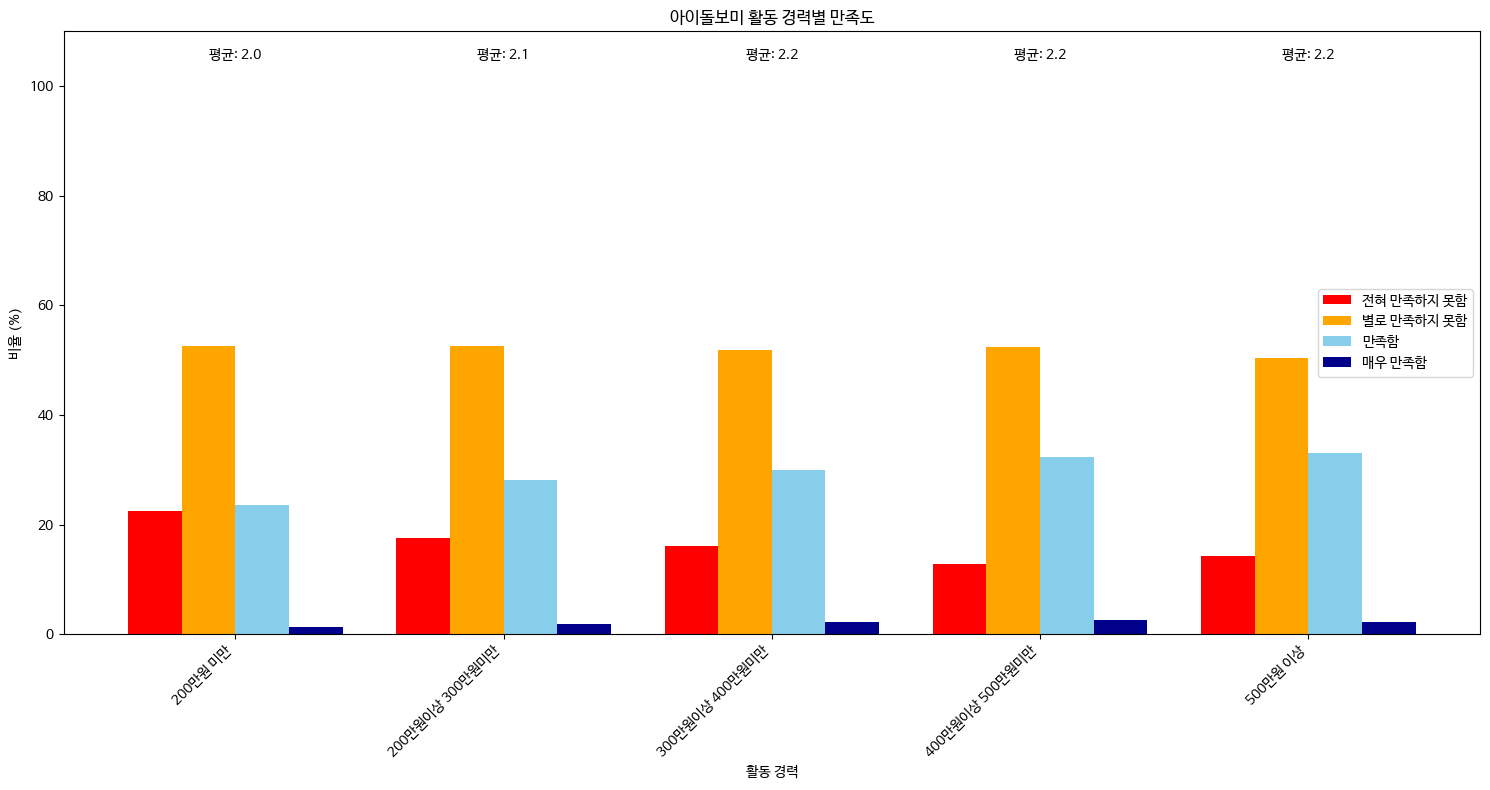

In [114]:
# 시각화
plt.figure(figsize=(15, 8))

# 막대 그래프 생성
bar_width = 0.2
index = range(len(income_satisfaction_df['월 평균 가구소득']))

plt.bar(index, income_satisfaction_df['전혀 만족하지 못함'], bar_width, label='전혀 만족하지 못함', color='red')
plt.bar([i + bar_width for i in index], income_satisfaction_df['별로 만족하지 못함'], bar_width, label='별로 만족하지 못함', color='orange')
plt.bar([i + 2 * bar_width for i in index], income_satisfaction_df['만족함'], bar_width, label='만족함', color='skyblue')
plt.bar([i + 3 * bar_width for i in index], income_satisfaction_df['매우 만족함'], bar_width, label='매우 만족함', color='darkblue')

plt.xlabel('활동 경력')
plt.ylabel('비율 (%)')
plt.title('아이돌보미 활동 경력별 만족도')
plt.xticks([i + 1.5 * bar_width for i in index], income_satisfaction_df['월 평균 가구소득'], rotation=45, ha='right')
plt.legend()

# 평균 점수 표시
for i, avg in enumerate(income_satisfaction_df['평균']):
    plt.text(i + 1.5 * bar_width, 105, f'평균: {avg}', ha='center')

plt.ylim(0, 110)  # y축 범위 설정

plt.tight_layout()
plt.show()

### 아이돌보미 활동소득별

In [115]:
# DataFrame 생성
activity_income_satisfaction_df = pd.DataFrame({
    '활동소득별 가구소득': ['50만원 미만', '50만원이상 80만원 미만', '80만원이상 100만원미만', '100만원이상 120만원미만', '120만원 이상'],
    '전혀 만족하지 못함': [34.8, 19.7, 13.3, 8.9, 5.6],
    '별로 만족하지 못함': [51.0, 59.1, 53.8, 54.4, 40.0],
    '만족함': [13.5, 20.7, 31.6, 35.9, 47.8],
    '매우 만족함': [0.7, 0.6, 1.3, 0.9, 6.6],
    '평균': [1.8, 2.0, 2.2, 2.3, 2.6],
    '표준편차': [0.7, 0.7, 0.7, 0.7, 0.7]
})

activity_income_satisfaction_df

,활동소득별 가구소득,전혀 만족하지 못함,별로 만족하지 못함,만족함,매우 만족함,평균,표준편차
0,50만원 미만,34.8,51.0,13.5,0.7,1.8,0.7
1,50만원이상 80만원 미만,19.7,59.1,20.7,0.6,2.0,0.7
2,80만원이상 100만원미만,13.3,53.8,31.6,1.3,2.2,0.7
3,100만원이상 120만원미만,8.9,54.4,35.9,0.9,2.3,0.7
4,120만원 이상,5.6,40.0,47.8,6.6,2.6,0.7


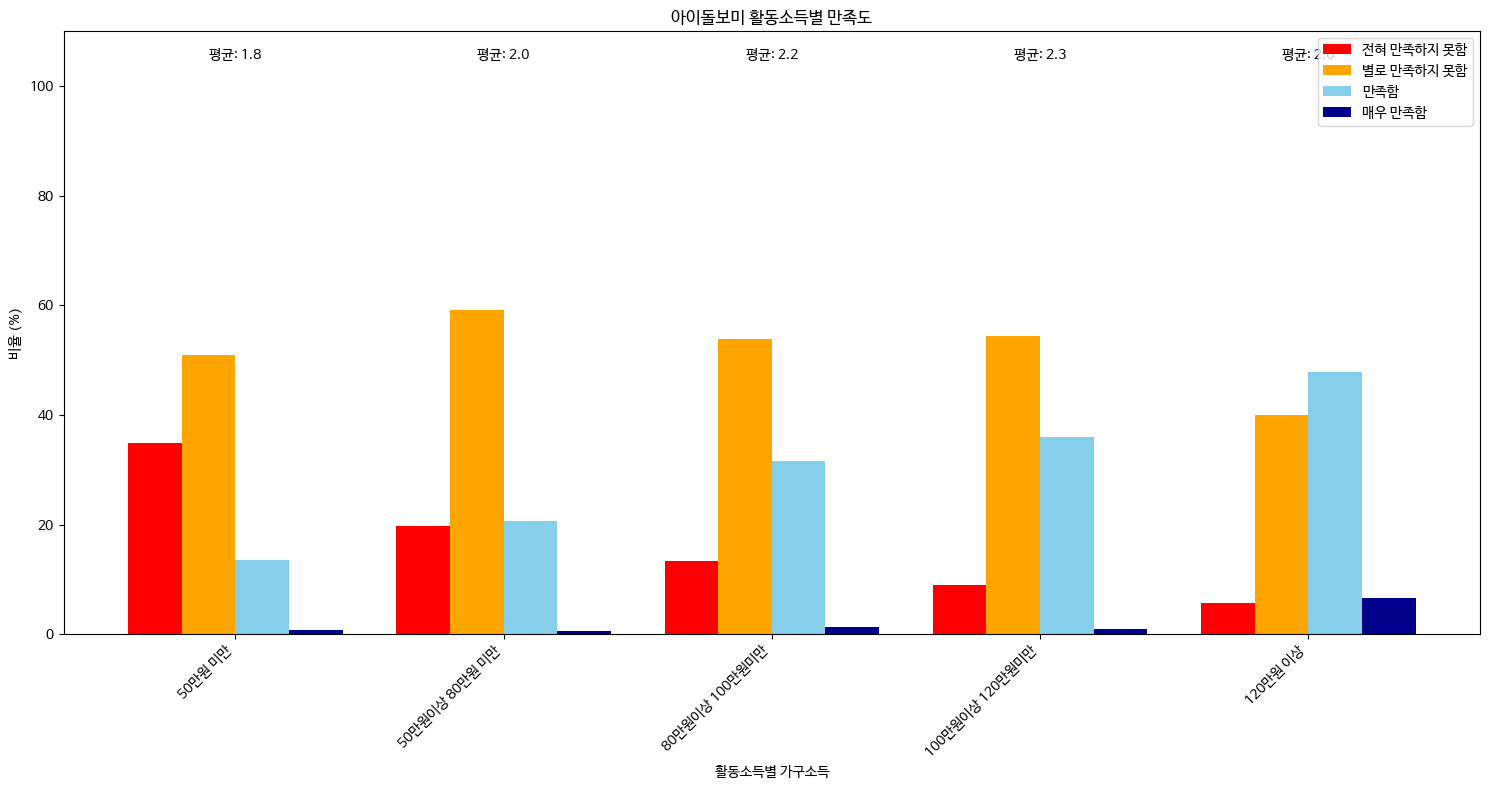

In [116]:
# 시각화
plt.figure(figsize=(15, 8))

# 막대 그래프 생성
bar_width = 0.2
index = range(len(activity_income_satisfaction_df['활동소득별 가구소득']))

plt.bar(index, activity_income_satisfaction_df['전혀 만족하지 못함'], bar_width, label='전혀 만족하지 못함', color='red')
plt.bar([i + bar_width for i in index], activity_income_satisfaction_df['별로 만족하지 못함'], bar_width, label='별로 만족하지 못함', color='orange')
plt.bar([i + 2 * bar_width for i in index], activity_income_satisfaction_df['만족함'], bar_width, label='만족함', color='skyblue')
plt.bar([i + 3 * bar_width for i in index], activity_income_satisfaction_df['매우 만족함'], bar_width, label='매우 만족함', color='darkblue')

plt.xlabel('활동소득별 가구소득')
plt.ylabel('비율 (%)')
plt.title('아이돌보미 활동소득별 만족도')
plt.xticks([i + 1.5 * bar_width for i in index], activity_income_satisfaction_df['활동소득별 가구소득'], rotation=45, ha='right')
plt.legend()

# 평균 점수 표시
for i, avg in enumerate(activity_income_satisfaction_df['평균']):
    plt.text(i + 1.5 * bar_width, 105, f'평균: {avg}', ha='center')

plt.ylim(0, 110)  # y축 범위 설정

plt.tight_layout()
plt.show()

### 아이돌보미 최종 학력별

In [118]:
# DataFrame 생성
graduration_satisfaction_df = pd.DataFrame({
    '최종학력': ['중학교 졸업 이하', '고등학교 졸업', '2-3년제 대학 졸업', '4년제 대학 졸업 이상'],
    '전혀 만족하지 못함': [15.6, 17.0, 18.8, 19.4],
    '별로 만족하지 못함': [50.2, 51.7, 52.9, 54.2],
    '만족함': [31.4, 29.0, 27.1, 25.5],
    '매우 만족함': [2.8, 2.3, 1.2, 0.9],
    '평균': [2.2, 2.2, 2.1, 2.1],
    '표준편차': [0.7, 0.7, 0.7, 0.7]
})

graduration_satisfaction_df

,최종학력,전혀 만족하지 못함,별로 만족하지 못함,만족함,매우 만족함,평균,표준편차
0,중학교 졸업 이하,15.6,50.2,31.4,2.8,2.2,0.7
1,고등학교 졸업,17.0,51.7,29.0,2.3,2.2,0.7
2,2-3년제 대학 졸업,18.8,52.9,27.1,1.2,2.1,0.7
3,4년제 대학 졸업 이상,19.4,54.2,25.5,0.9,2.1,0.7


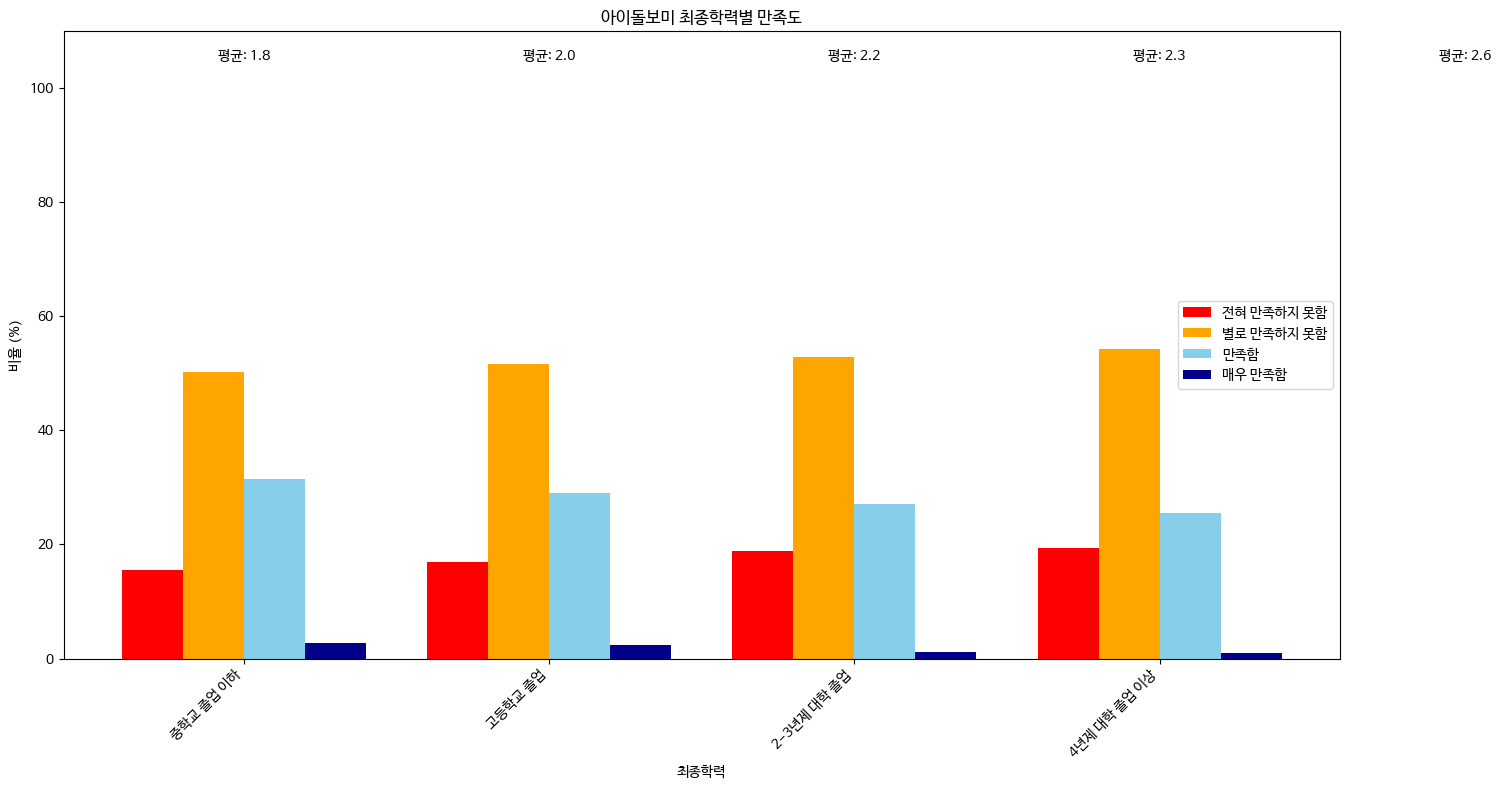

In [119]:
# 시각화
plt.figure(figsize=(15, 8))

# 막대 그래프 생성
bar_width = 0.2
index = range(len(graduration_satisfaction_df['최종학력']))

plt.bar(index, graduration_satisfaction_df['전혀 만족하지 못함'], bar_width, label='전혀 만족하지 못함', color='red')
plt.bar([i + bar_width for i in index], graduration_satisfaction_df['별로 만족하지 못함'], bar_width, label='별로 만족하지 못함', color='orange')
plt.bar([i + 2 * bar_width for i in index], graduration_satisfaction_df['만족함'], bar_width, label='만족함', color='skyblue')
plt.bar([i + 3 * bar_width for i in index], graduration_satisfaction_df['매우 만족함'], bar_width, label='매우 만족함', color='darkblue')

plt.xlabel('최종학력')
plt.ylabel('비율 (%)')
plt.title('아이돌보미 최종학력별 만족도')
plt.xticks([i + 1.5 * bar_width for i in index], graduration_satisfaction_df['최종학력'], rotation=45, ha='right')
plt.legend()

# 평균 점수 표시
for i, avg in enumerate(activity_income_satisfaction_df['평균']):
    plt.text(i + 1.5 * bar_width, 105, f'평균: {avg}', ha='center')

plt.ylim(0, 110)  # y축 범위 설정

plt.tight_layout()
plt.show()